In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models 
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

In [ ]:
# https://www.kaggle.com/datasets/arjuntejaswi/plant-village?resource=download

IMAGE_SIZE = 256
BATCH_SIZE = 32
RGB_CHANNELS = 3
DATA_DIR = Path.cwd().parent / 'data' / 'PlantVillage'


dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR, 
    shuffle=True, 
    image_size=(IMAGE_SIZE, IMAGE_SIZE), 
    batch_size=BATCH_SIZE
)

Found 20638 files belonging to 15 classes.


In [7]:
class_names = dataset.class_names
print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
# 20638 files/images divided into 32 batch size ~= 644 batches
len(dataset) 

645

In [ ]:
# image_batch is a tensor of shape (32, 256, 256, 3) -> (batch_size, height, width, channels)
# label_batch is a tensor of shape (32,) -> (batch_size,)
# 15 classes in total, so label_batch contains integers from 0 to 14 representing the class indices.
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())


(32, 256, 256, 3)
[ 5  0 11  1 11  6  1  8 10  1  9  1 14  1 10 14  7  5 12  5 12  2  0 14
 10 12 12  5  5  7  7 11]


In [20]:
for i in dataset.take(1):
    print(i[0].shape)

(32, 256, 256, 3)


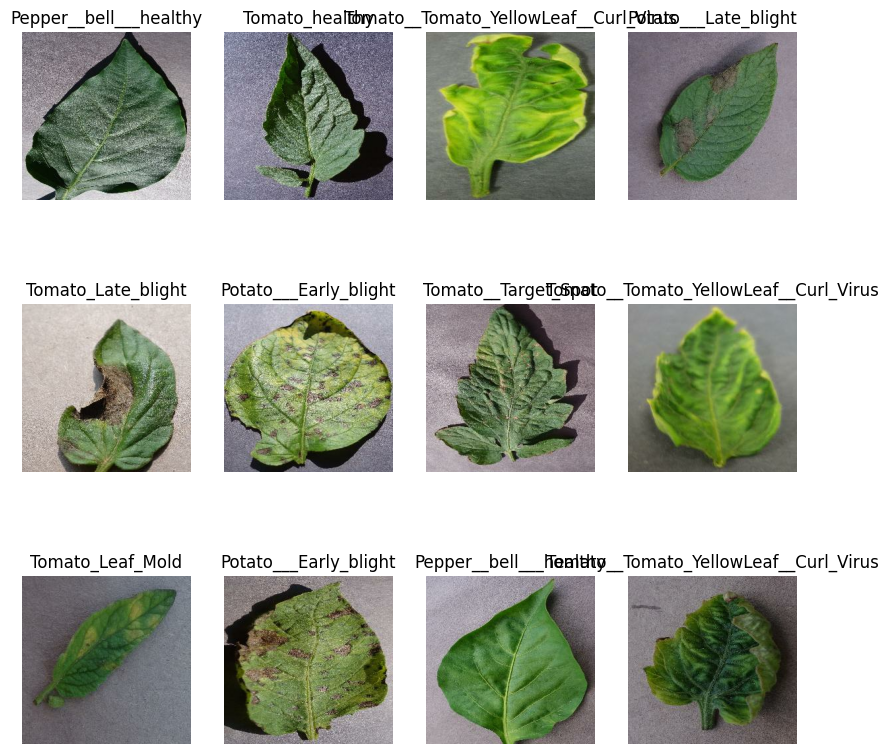

In [37]:
plt.figure(figsize=(10, 10))

for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis('off')
        plt.title(class_names[label_batch[i]])